### Analysing results from individual experiments

This notebook contains analysis of the results created throught the experiment in quantum_representation.ipynb. It impors the log files in this directory.

In [67]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import math
from mpl_toolkits import mplot3d

In [143]:
m=j=50
M, J = np.meshgrid(np.arange(5, m), np.arange(5, j))

In [144]:
results_rqmga = np.empty_like(M)
results_rkqmga = np.empty_like(M)
results1 = np.empty_like(M)

In [145]:
math.factorial(5)**5

24883200000

In [146]:
M.shape

(45, 45)

In [147]:
ref_high = 2**(20*20*(math.floor(math.log2(20-1))+1))

In [153]:
for k in range(M.shape[0]):
    for i in range(M.shape[1]):
        cur_m = int(M[k, i])
        cur_j = int(J[k, i])
        numerator = math.factorial(cur_m * cur_j)
        denominator = math.factorial(cur_m)**cur_j
        n_permutations = numerator // denominator
        value = (n_permutations) - 1  

        rqmga = (math.floor(math.log2(value)) + 1)

        rkqmga = (cur_j*cur_m*(math.floor(math.log2(cur_j-1))+1))
        results_rqmga[k, i] = rqmga
        results_rkqmga[k, i] = rkqmga
        results1[k, i] = rkqmga-rqmga

    

In [160]:
results_rkqmga - results_rqmga

array([[  25,   29,   33, ...,  174,  178,  181],
       [  23,   26,   29, ...,  136,  138,  141],
       [  20,   22,   24, ...,   86,   88,   89],
       ...,
       [ 217,  244,  270, ..., 1169, 1191, 1213],
       [ 214,  240,  265, ..., 1126, 1147, 1167],
       [ 212,  237,  261, ..., 1081, 1101, 1120]])

In [157]:
results1

array([[  25,   29,   33, ...,  174,  178,  181],
       [  23,   26,   29, ...,  136,  138,  141],
       [  20,   22,   24, ...,   86,   88,   89],
       ...,
       [ 217,  244,  270, ..., 1169, 1191, 1213],
       [ 214,  240,  265, ..., 1126, 1147, 1167],
       [ 212,  237,  261, ..., 1081, 1101, 1120]])

In [158]:
rqmga

13286

In [159]:
rkqmga

14406

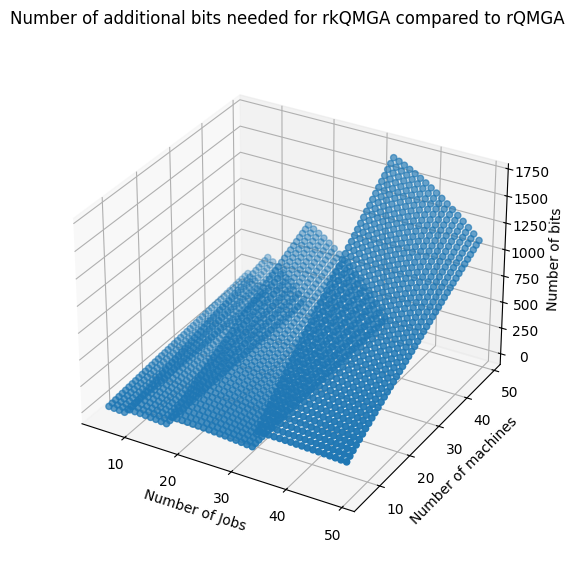

In [161]:
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection ='3d')
ax.scatter3D(J.ravel(), M.ravel(), results1.ravel())
#ax.scatter3D(J.ravel(), M.ravel(), results_rkqmga.ravel(), label="rkQMGA")
ax.set_title('Number of additional bits needed for rkQMGA compared to rQMGA')
ax.set_xlabel("Number of Jobs")
ax.set_ylabel("Number of machines")
ax.set_zlabel("Number of bits")
ax.set_box_aspect(None, zoom=0.9)
plt.show()

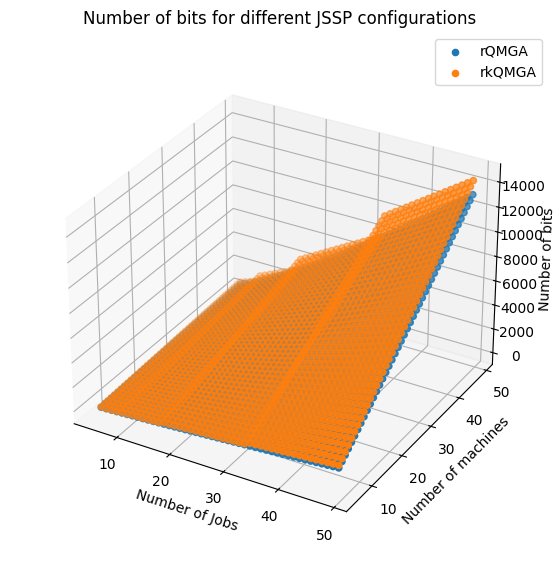

In [152]:
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection ='3d')
ax.scatter3D(J.ravel(), M.ravel(), results_rqmga.ravel(), label="rQMGA")
ax.scatter3D(J.ravel(), M.ravel(), results_rkqmga.ravel(), label="rkQMGA")
ax.set_title('Number of bits for different JSSP configurations')
ax.set_xlabel("Number of Jobs")
ax.set_ylabel("Number of machines")
ax.set_zlabel("Number of bits")
ax.set_box_aspect(None, zoom=0.9)
plt.legend()
plt.show()

Import datasets and concatenate them

In [142]:
first_df = pd.read_csv("Chromosome_decoding_test_measurements_improved.csv").drop(columns=["Unnamed: 0"])
log_data = first_df
#first_df["Method"] = "Hash New 2"
#second_df = pd.read_csv("Chromosome_decoding_test_measurements.csv").drop(columns=["Unnamed: 0"])
#second_df = second_df[~second_df["Method"].isin(["Hash base", "Hash New"])]
# Concatenate datasets
#log_data = pd.concat([first_df, second_df])

FileNotFoundError: [Errno 2] No such file or directory: 'Chromosome_decoding_test_measurements_improved.csv'

NameError: name 'log_data' is not defined

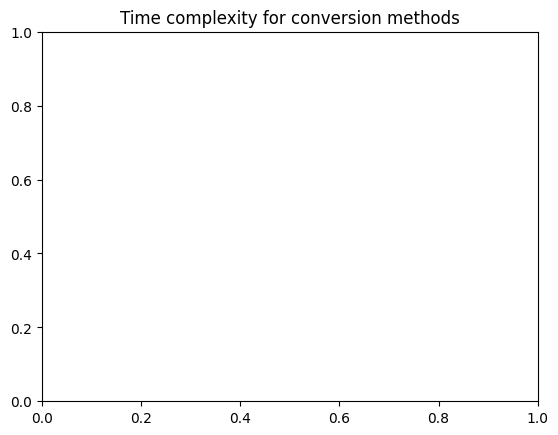

In [141]:
plt.title("Time complexity for conversion methods")
sns.lineplot(log_data, x="N", y="Decoding_time", hue="Method")

An important aspect of the conversion between binary and integer representations is the how the probability of reaching each solution in the search space. In the follwoing cells, the distribution of solutions in the search spaces are examined.

Read data from disk

In [5]:
dataset_dtypes = pd.read_csv("Chromosome_decoding_test_redundancy_jm3_dtypes.csv").drop(columns=["Unnamed: 0"])
df_redundancy = pd.read_csv("Chromosome_decoding_test_redundancy_jm3.csv", dtype=dataset_dtypes["0"].to_numpy()).drop(columns=["Unnamed: 0"])
df_redundancy["String Length"] = df_redundancy["Binary"].apply(lambda x: len(str(x)))

Next, an Id value is assigned to each unique permutation

In [6]:
temp_permutation_id = pd.Series(df_redundancy["Permutation"].unique()).reset_index().rename(columns={0 : "Permutation", "index" : "PermId"})
df_redundancy = df_redundancy.merge(right=temp_permutation_id, on="Permutation")

An important aspect of the conversion between binary and integer representations is how the probability of reaching each solution in the search space. In the follwoing cells, the distribution of solutions in the search spaces are examined.

In [7]:
unique_df = df_redundancy.groupby(["Method", "N", "String Length"]).agg(lambda x: len(np.unique(x)))
unique_df

,,,Permutation,Binary,Binary_value,Decoding_time,PermId
Method,N,String Length,,,,,
rQMGA,4,26,99919,99930,99930,1900,99919
rkQMGA,4,32,99681,100000,100000,2072,99681


Note that the Hash methods for the Multiset representation uses significantly less binary strings to represent the same amount of Permutations of a Multiset. It is also important to note that the Permutation covers significantly less of the search space.

In [8]:
df_redundancy.groupby(["Method"])[["Permutation", "PermId"]].value_counts()

Method  Permutation       PermId
rQMGA   0030212312012313  38363     2
        0103001332112232  133575    2
        0103022313201312  46135     2
        0113000122213323  128910    2
        0113130123203022  17004     2
                                   ..
rkQMGA  3333122210010201  68547     1
        3333201001220112  65805     1
        3333202020201111  117970    1
        3333212010221001  4360      1
        3333220020111012  62351     1
Name: count, Length: 199600, dtype: int64

In [9]:
temp_df = df_redundancy.groupby(["Method", "PermId"])["Permutation"].value_counts().reset_index()
temp_df.groupby(["Method"]).agg({"count" : ["min", "max", "std"]})

count              
         min max       std
Method                    
rQMGA      1   2  0.028461
rkQMGA     1   3  0.056657

In [10]:
unique_2 = df_redundancy.groupby(["Method", "Permutation", "PermId"]).agg(lambda x: len(np.unique(x)))#len(np.unique(x)))
unique_2


N  Binary  Binary_value  Decoding_time  \
Method Permutation      PermId                                           
rQMGA  0000111223233231 111833  1       1             1              1   
       0000111323223312 133959  1       1             1              1   
       0000111332213223 197399  1       1             1              1   
       0000111332322213 19104   1       1             1              1   
       0000112113322332 48298   1       1             1              1   
...                            ..     ...           ...            ...   
rkQMGA 3333122210010201 68547   1       1             1              1   
       3333201001220112 65805   1       1             1              1   
       3333202020201111 117970  1       1             1              1   
       3333212010221001 4360    1       1             1              1   
       3333220020111012 62351   1       1             1              1   

                                String Length  
Method Permutation      PermId                 
rQMGA  0000111223233231 111833              1  
       0000111323223312 133959              1  
       0000111332213223 197399              1  
       0000111332322213 19104               1  
       0000112113322332 48298               1  
...                                       ...  
rkQMGA 3333122210010201 68547               1  
       3333201001220112 65805               1  
       3333202020201111 117970              1  
       3333212010221001 4360                1  
       3333220020111012 62351               1  

[199600 rows x 5 columns]

In [11]:
unique_2.reset_index(drop=False).groupby("Method").agg({"Binary" : ["max", "min", "std"]})

Binary              
          max min       std
Method                     
rQMGA       2   1  0.010492
rkQMGA      3   1  0.056657

The follwoing histograms visualize the frequency of each permutations in the test data.

In [12]:
plot_df_2 = df_redundancy[["PermId", "Binary_value", "Method"]]

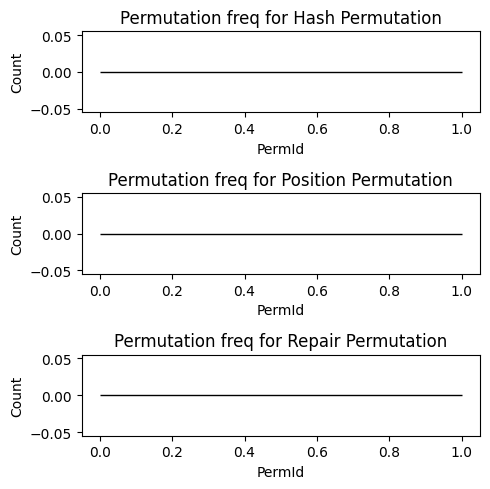

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(5, 5))

sns.histplot(data=plot_df_2[plot_df_2["Method"].isin(["Hash Permutation"])], x="PermId", color="blue", ax=ax[0])
ax[0].set_title("Permutation freq for Hash Permutation")

sns.histplot(data=plot_df_2[plot_df_2["Method"].isin(["Position Permutation"])], x="PermId", color="orange", ax=ax[1])
ax[1].set_title("Permutation freq for Position Permutation")

sns.histplot(data=plot_df_2[plot_df_2["Method"].isin(["Repair Permutation"])], x="PermId", color="green", ax=ax[2])
ax[2].set_title("Permutation freq for Repair Permutation")

plt.tight_layout()

From this plot we can see that the minimum frequency for any permutation looks to be higher for hash permutation  method. Note that the spacing comes from that the permutation ids were created for the muliset methods which cover significanly more of the search space. One can alos see that the search space somehow is groped together. Here it would be interesting to investigate the order in which the permutations were given id's to see if there is a pattern here.

it looks like the grouping of higher frequencies on the left is related to the fact that they are more probable and thus more likely to be among the first drawn permutations.

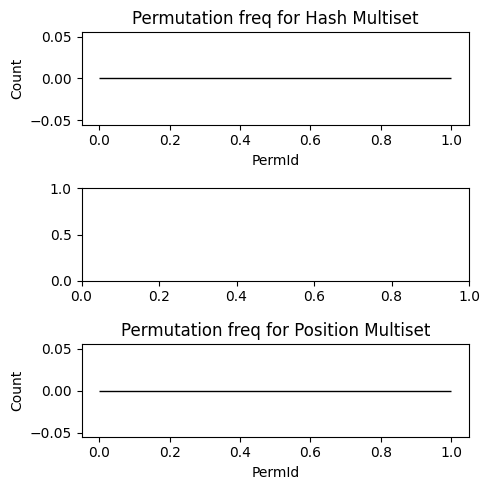

In [14]:
fig, ax = plt.subplots(3, 1, figsize=(5, 5))
sns.histplot(data=plot_df_2[plot_df_2["Method"].isin(["Hash Multiset"])], x="PermId", color="orange", ax=ax[0])
ax[0].set_title("Permutation freq for Hash Multiset")

#sns.histplot(data=plot_df_2[plot_df_2["Method"].isin(["Hash Multiset*"])], x="PermId", color="blue", ax=ax[1])
#ax[1].set_title("Permutation freq for Hash Multiset*")

sns.histplot(data=plot_df_2[plot_df_2["Method"].isin(["Position Multiset"])], x="PermId", color="green", ax=ax[2])
ax[2].set_title("Permutation freq for Position Multiset")
plt.tight_layout()

The following plots show how many unique binary string there exists for each permutation

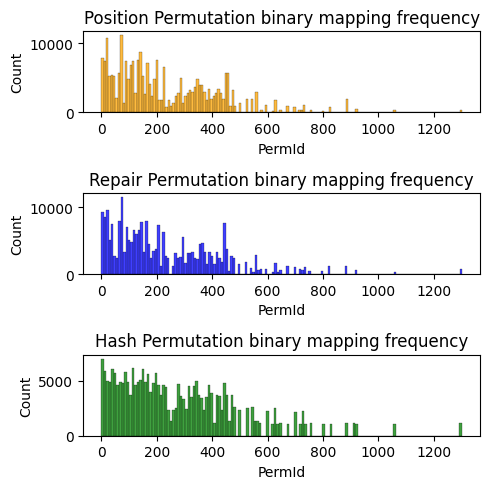

In [8]:
df_plot_1 = df_redundancy.drop_duplicates(["Method", "Binary"], keep="first")

fig, ax = plt.subplots(3, 1, figsize=(5, 5))

sns.histplot(data=df_plot_1[df_plot_1["Method"].isin(["Position Permutation"])], x="PermId", color="orange", ax=ax[0])
ax[0].set_title("Position Permutation binary mapping frequency")

sns.histplot(data=df_plot_1[df_plot_1["Method"].isin(["Repair Permutation"])], x="PermId", color="blue", ax=ax[1])
ax[1].set_title("Repair Permutation binary mapping frequency")

sns.histplot(data=df_plot_1[df_plot_1["Method"].isin(["Hash Permutation"])], x="PermId", color="green", ax=ax[2])
ax[2].set_title("Hash Permutation binary mapping frequency")

plt.tight_layout()

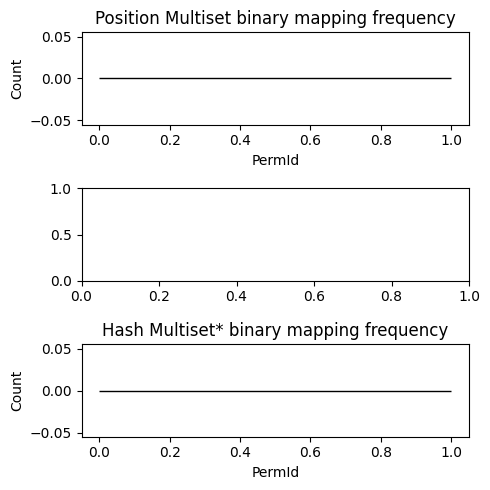

In [15]:
df_plot_1 = df_redundancy.drop_duplicates(["Method", "Binary"], keep="first")

fig, ax = plt.subplots(3, 1, figsize=(5, 5))

sns.histplot(data=df_plot_1[df_plot_1["Method"].isin(["Position Multiset"])], x="PermId", color="orange", ax=ax[0])
ax[0].set_title("Position Multiset binary mapping frequency")

#sns.histplot(data=df_plot_1[df_plot_1["Method"].isin(["Hash Multiset"])], x="PermId", color="blue", ax=ax[1])
#ax[1].set_title("Repair Multiset binary mapping frequency")

sns.histplot(data=df_plot_1[df_plot_1["Method"].isin(["Hash Multiset*"])], x="PermId", color="green", ax=ax[2])
ax[2].set_title("Hash Multiset* binary mapping frequency")

plt.tight_layout()

Note how the frequency values are higher in the plot. This is explained by that the bins cover several permutations.

In [20]:
df_plot_1.groupby(["Method"])["PermId"].value_counts().reset_index().groupby(["Method"]).agg({"count" : ["min", "max", "std"]})

count                   
                       min   max          std
Method                                       
Hash Multiset            9    10     0.431758
Hash Multiset*           9    10     0.431758
Hash Permutation       971  1313    91.467539
Position Multiset       19   956    95.827560
Position Permutation    64  7845  1001.511761
Repair Permutation     208  7819  1001.243712

<Axes: xlabel='PermId', ylabel='Binary'>

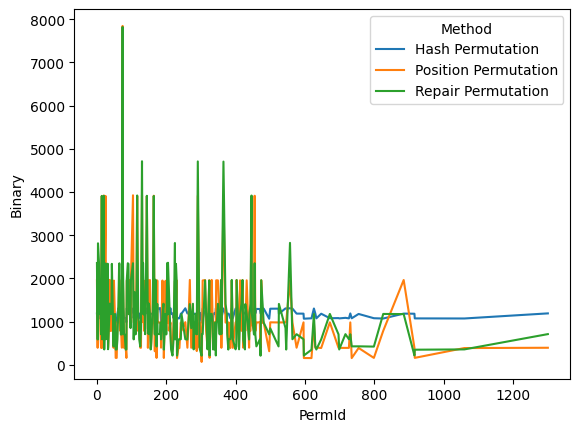

In [ ]:
plot_df_1 = unique_2.reset_index().reset_index()
sns.lineplot(data=plot_df_1[plot_df_1["Method"].isin(["Position Permutation", "Hash Permutation", "Repair Permutation"])], x="PermId", y="Binary", hue="Method")

<Axes: xlabel='PermId', ylabel='Binary'>

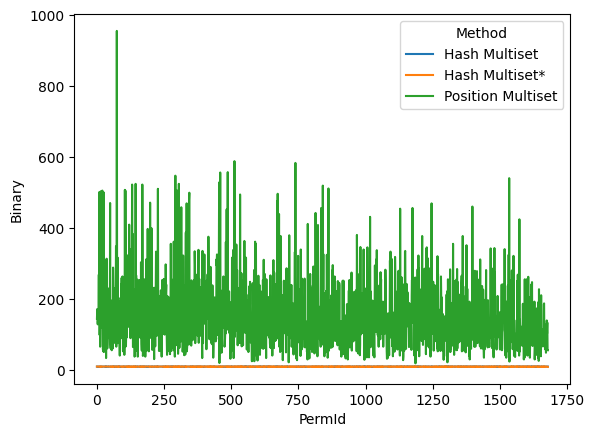

In [13]:
sns.lineplot(data=plot_df_1[plot_df_1["Method"].isin(["Hash Multiset", "Hash Multiset*", "Position Multiset"])], x="PermId", y="Binary", hue="Method")

One thing we can observe from the above is that, despite the number of unique binary strings for each permutation is significantly better for the hash functions, the frequency of each permutation ocuring is relatively good spaced for the position base also. Can this be explained with the theory of big numbers?